<a href="https://colab.research.google.com/github/paulorsf29/Projeto_ComparacaoAlgoritmica_ACO_BuscaGulosa/blob/main/ACO_GULOSA_ALGORITMOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Matriz de Distâncias Calculada (Fator 1.29 aplicado).

🚀 INICIANDO BATALHA: GULOSO vs ACO PURO
N     Guloso(km)   Tempo(s)   ACO(km)    Tempo(s)   Melhoria ACO
-----------------------------------------------------------------
6     374.1        0.0000     344.6      0.1321     7.9       %
12    947.2        0.0000     782.7      0.6089     17.4      %
24    1483.9       0.0002     1328.8     6.3307     10.5      %
36    1945.0       0.0003     1603.2     13.5906    17.6      %
48    2046.4       0.0005     1950.7     24.5544    4.7       %


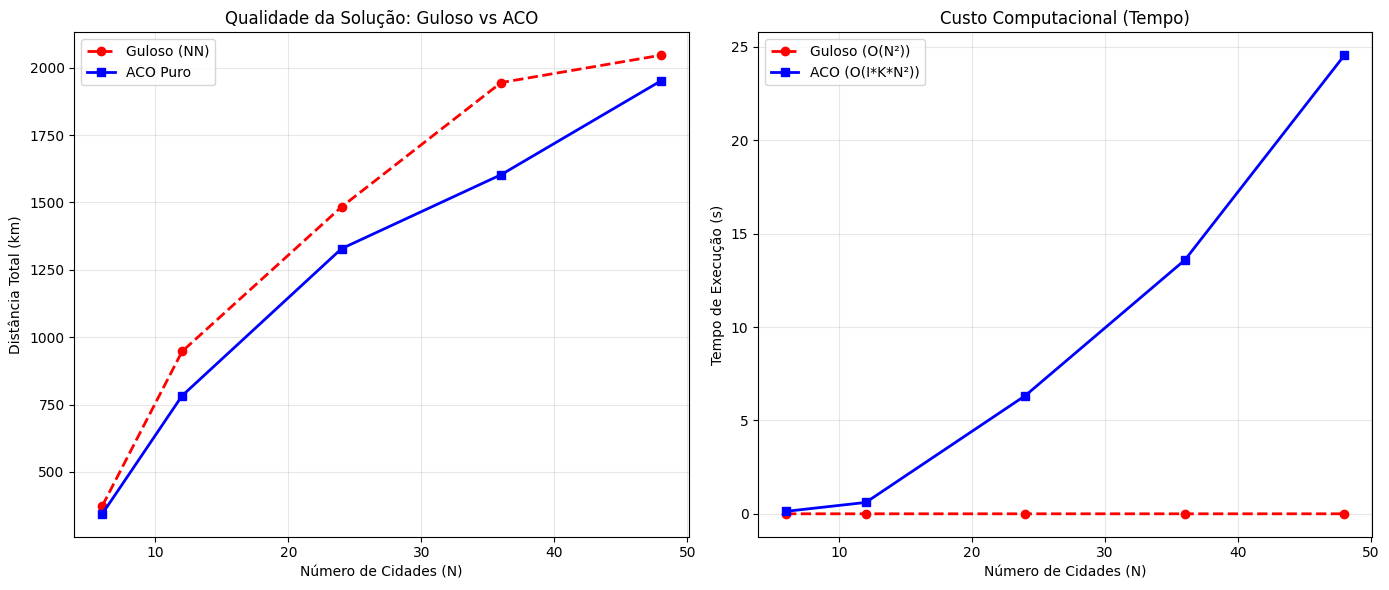

In [ ]:
# @title ⚔️ Arena de Algoritmos: Guloso (NN) vs. Meta-heurística (ACO Puro)
import numpy as np
import random
import matplotlib.pyplot as plt
import math
import time

# =============================================================================
# 1. DADOS E PREPARAÇÃO (CIDADES E DISTÂNCIAS)
# =============================================================================
cidades_coords = {
    '1. Angicos': (-5.656, -36.608), '2. São Rafael': (-5.801, -36.883),
    '3. Itajá': (-5.642, -36.868), '4. Assú': (-5.574, -36.906),
    '5. Jucurutu': (-6.033, -37.020), '6. Mossoró': (-5.188, -37.344),
    '7. Natal': (-5.794, -35.211), '8. Afonso Bezerra': (-5.499, -36.506),
    '9. Pedro Avelino': (-5.523, -36.388), '10. F. Pedrosa': (-5.690, -36.520),
    '11. Santana Matos': (-5.958, -36.657), '12. Lajes': (-5.687, -36.248),
    '13. Santa Cruz': (-6.226, -36.020), '14. Caicó': (-6.458, -37.098),
    '15. São Miguel': (-6.210, -38.497), '16. S. José Mipibú': (-6.075, -35.236),
    '17. S. Gonçalo': (-5.793, -35.331), '18. Pau dos Ferros': (-6.112, -38.204),
    '19. Parnamirim': (-5.914, -35.263), '20. Macaíba': (-5.856, -35.355),
    '21. Macau': (-5.113, -36.634), '22. João Câmara': (-5.537, -35.818),
    '23. Ipanguaçu': (-5.498, -36.852), '24. Currais Novos': (-6.260, -36.516),
    '25. Ceará-Mirim': (-5.631, -35.425), '26. Canguaretama': (-6.379, -35.128),
    '27. Baraúna': (-5.076, -37.617), '28. Apodi': (-5.662, -37.798),
    '29. Acari': (-6.436, -36.636), '30. Areia Branca': (-4.956, -37.136),
    '31. Extremoz': (-5.705, -35.305), '32. Goianinha': (-6.266, -35.207),
    '33. Monte Alegre': (-6.068, -35.326), '34. Nísia Floresta': (-6.091, -35.207),
    '35. Nova Cruz': (-6.478, -35.435), '36. Touros': (-5.197, -35.460),
    '37. Tangará': (-6.200, -35.800), '38. SP do Potengi': (-5.890, -35.760),
    '39. Santo Antônio': (-6.310, -35.470), '40. Taipu': (-5.630, -35.600),
    '41. Upanema': (-5.640, -37.250), '42. Pedro Velho': (-6.440, -35.220),
    '43. Parelhas': (-6.690, -36.650), '44. Caraúbas': (-5.790, -37.560),
    '45. Alexandria': (-6.410, -38.010), '46. J. de Piranhas': (-6.620, -37.350),
    '47. SJ Campestre': (-6.310, -35.720), '48. Poço Branco': (-5.620, -35.660)
}

coords = list(cidades_coords.values())

def haversine_distance(coord1, coord2):
    R = 6371
    lat1, lon1 = math.radians(coord1[0]), math.radians(coord1[1])
    lat2, lon2 = math.radians(coord2[0]), math.radians(coord2[1])
    a = math.sin((lat2-lat1)/2)**2 + math.cos(lat1)*math.cos(lat2) * math.sin((lon2-lon1)/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def calcular_distancias_reais(coordenadas):
    n = len(coordenadas)
    matriz = np.zeros((n, n))
    FATOR_TORTUOSIDADE = 1.29 # Ajuste para estradas reais
    for i in range(n):
        for j in range(n):
            if i != j:
                dist = haversine_distance(coordenadas[i], coordenadas[j])
                matriz[i][j] = dist * FATOR_TORTUOSIDADE
    return matriz

distancias_base = calcular_distancias_reais(coords)
print(f"✅ Matriz de Distâncias Calculada (Fator 1.29 aplicado).")

# =============================================================================
# 2. ALGORITMO 1: VIZINHO MAIS PRÓXIMO (GULOSO - O(N^2))
# =============================================================================
def vizinho_mais_proximo(matriz_distancias, ponto_partida=0):
    n = len(matriz_distancias)
    visitadas = {ponto_partida}
    rota = [ponto_partida]
    atual = ponto_partida
    custo_total = 0

    # Enquanto houver cidades não visitadas
    while len(visitadas) < n:
        melhor_prox = -1
        menor_dist = float('inf')

        # Varre todas para achar a mais próxima (Greedy)
        for prox in range(n):
            if prox not in visitadas:
                dist = matriz_distancias[atual][prox]
                if dist < menor_dist:
                    menor_dist = dist
                    melhor_prox = prox

        visitadas.add(melhor_prox)
        rota.append(melhor_prox)
        custo_total += menor_dist
        atual = melhor_prox

    # Fecha o ciclo
    custo_total += matriz_distancias[atual][ponto_partida]
    rota.append(ponto_partida)

    return rota, custo_total

# =============================================================================
# 3. ALGORITMO 2: ACO PURO (META-HEURÍSTICA - O(I*K*N²))
# =============================================================================
class AntColonyOptimizer:
    def __init__(self, distancias, n_formigas, n_iteracoes, alpha, beta, rho, Q, feromonio_inicial):
        #Inicialização dos Parâmetros
        self.distancias = distancias  # Matriz de distâncias (N x N)
        self.n_cidades = len(distancias)
        self.n_formigas = n_formigas  # Quantas formigas vão explorar por rodada
        self.n_iteracoes = n_iteracoes # Quantas vezes o processo se repete

        #Parâmetros da Fórmula de Probabilidade
        self.alpha = alpha  # Peso do Feromônio (Histórico)
        self.beta = beta    # Peso da Visibilidade (Distância imediata)

        # Parâmetros de Atualização
        self.rho = rho      # Taxa de Evaporação (0.05 significa que 5% do rastro some)
        self.Q = Q          # Quantidade de feromônio que a formiga deposita

        # Cria a matriz de feromônios inicial com valor fixo (ex: 0.1)
        self.feromonios = np.full((self.n_cidades, self.n_cidades), feromonio_inicial)

        # --- Cálculo da Visibilidade (Heurística) ---
        # A visibilidade (eta) é o inverso da distância (1 / d).
        # Cidades mais perto têm valor maior, atraindo mais a formiga.
        with np.errstate(divide='ignore'): # Ignora erro de divisão por zero na diagonal
            self.eta = 1 / distancias
            self.eta[self.eta == np.inf] = 0 # Corrige o infinito na diagonal (distância 0)

    def selecionar_proxima(self, atual, visitadas):
        """
        O CÉREBRO DA FORMIGA: Decide para onde ir usando a Roleta Viciada.
        Complexidade: O(N) (pois avalia todas as cidades vizinhas)
        """
        # 1. Calcula o peso do feromônio (Rastro deixado)
        feromonio = np.power(self.feromonios[atual], self.alpha)

        # 2. Calcula o peso da visibilidade (Proximidade)
        visibilidade = np.power(self.eta[atual], self.beta)

        # 3. Combina os dois para ter a probabilidade bruta
        probs = feromonio * visibilidade

        # 4. Zera a chance de ir para cidades onde ela já passou
        probs[list(visitadas)] = 0

        # 5. Normaliza para virar porcentagem (soma = 1)
        soma = probs.sum()
        if soma == 0:
            # Segurança: se não tiver opção lógica, escolhe aleatório entre as não visitadas
            return random.choice([i for i in range(self.n_cidades) if i not in visitadas])

        # 6. Escolha Probabilística (Roleta)
        return np.random.choice(range(self.n_cidades), p=probs/soma)

    def rodar(self):
        """
        O MOTOR DO ALGORITMO: Executa as iterações.
        Complexidade Total: O(Iterações * Formigas * Cidades^2)
        """
        melhor_rota, melhor_custo = None, float('inf')

        # Loop Principal (Iterações)
        for _ in range(self.n_iteracoes):
            rotas, custos = [], []

            # Cada formiga constrói uma solução completa
            for _ in range(self.n_formigas):
                # Começa em uma cidade aleatória
                atual = random.randint(0, self.n_cidades - 1)
                rota = [atual]
                visitadas = {atual}
                custo = 0

                # Passo a passo da construção da rota (N-1 passos)
                for _ in range(self.n_cidades - 1):
                    prox = self.selecionar_proxima(atual, visitadas)
                    custo += self.distancias[atual][prox] # Soma distância
                    rota.append(prox)
                    visitadas.add(prox)
                    atual = prox

                # Fecha o ciclo (volta para o início)
                custo += self.distancias[rota[-1]][rota[0]]
                rota.append(rota[0])

                # Guarda a rota desta formiga
                rotas.append(rota)
                custos.append(custo)

                # Verifica se é a melhor solução global até agora
                if custo < melhor_custo:
                    melhor_custo, melhor_rota = custo, rota

            #ATUALIZAÇÃO DOS FEROMÔNIOS (Fim da iteração)

            # 1. Evaporação: Todo o rastro antigo diminui um pouco (fator rho)
            self.feromonios *= (1 - self.rho)

            # 2. Depósito: Todas as formigas adicionam feromônio nas rotas que fizeram
            for i in range(self.n_formigas):
                # Quanto menor o custo (distância), mais feromônio (dt) ela deposita
                dt = self.Q / custos[i]

                for j in range(len(rotas[i]) - 1):
                    u, v = rotas[i][j], rotas[i][j+1]
                    # Adiciona rastro na ida e na volta (grafo não direcionado)
                    self.feromonios[u][v] += dt
                    self.feromonios[v][u] += dt

        return melhor_rota, melhor_custo

# =============================================================================
# 4. EXECUÇÃO DO EXPERIMENTO COMPARATIVO
# =============================================================================
instancias = {
    6: [0, 1, 2, 3, 4, 5],
    12: list(range(12)),
    24: list(range(24)),
    36: list(range(36)),
    48: list(range(48))
}

resultados = {'Guloso': [], 'ACO': []}
tempos = {'Guloso': [], 'ACO': []}
tamanhos = sorted(instancias.keys())

print(f"\n🚀 INICIANDO BATALHA: GULOSO vs ACO PURO")
print(f"{'N':<5} {'Guloso(km)':<12} {'Tempo(s)':<10} {'ACO(km)':<10} {'Tempo(s)':<10} {'Melhoria ACO':<12}")
print("-" * 65)

for n in tamanhos:
    indices = instancias[n]
    dist_instancia = distancias_base[np.ix_(indices, indices)]

    #1. Roda Guloso
    inicio = time.time()
    _, custo_nn = vizinho_mais_proximo(dist_instancia)
    tempo_nn = time.time() - inicio

    #2. Roda ACO
    # Parâmetros otimizados para qualidade
    if n <= 12:
        params = {'alpha': 0.9, 'beta': 1.5, 'rho': 0.05, 'Q': 100, 'iter': 100}
    else:
        params = {'alpha': 1.5, 'beta': 2.0, 'rho': 0.05, 'Q': 100, 'iter': 200}

    inicio = time.time()
    aco = AntColonyOptimizer(dist_instancia, n, params['iter'], params['alpha'], params['beta'], params['rho'], params['Q'], 0.1)
    _, custo_aco = aco.rodar()
    tempo_aco = time.time() - inicio

    # Salva dados
    resultados['Guloso'].append(custo_nn)
    resultados['ACO'].append(custo_aco)
    tempos['Guloso'].append(tempo_nn)
    tempos['ACO'].append(tempo_aco)

    ganho = ((custo_nn - custo_aco) / custo_nn) * 100
    print(f"{n:<5} {custo_nn:<12.1f} {tempo_nn:<10.4f} {custo_aco:<10.1f} {tempo_aco:<10.4f} {ganho:<10.1f}%")

# =============================================================================
# 5. GRÁFICOS (EVIDÊNCIA PARA O RELATÓRIO)
# =============================================================================
plt.figure(figsize=(14, 6))

# Gráfico 1: Comparativo de Qualidade (Distância)
plt.subplot(1, 2, 1)
plt.plot(tamanhos, resultados['Guloso'], 'r--o', label='Guloso (NN)', linewidth=2)
plt.plot(tamanhos, resultados['ACO'], 'b-s', label='ACO Puro', linewidth=2)
plt.title('Qualidade da Solução: Guloso vs ACO')
plt.xlabel('Número de Cidades (N)')
plt.ylabel('Distância Total (km)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Comparativo de Tempo (Trade-off)
plt.subplot(1, 2, 2)
plt.plot(tamanhos, tempos['Guloso'], 'r--o', label='Guloso (O(N²))', linewidth=2)
plt.plot(tamanhos, tempos['ACO'], 'b-s', label='ACO (O(I*K*N²))', linewidth=2)
plt.title('Custo Computacional (Tempo)')
plt.xlabel('Número de Cidades (N)')
plt.ylabel('Tempo de Execução (s)')
# Escala logarítmica é opcional, mas ajuda a ver o Guloso que é quase 0
# plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()